# Các phương pháp phòng thủ trên model Logistic Regression

Sau khi đã "nhận biết" (awareness) được rằng dữ liệu huấn luyện có thể bị đầu độc bằng label flipping (xem `02-anwareness-attack.ipynb`), notebook này thử nghiệm các hướng **phòng thủ (defend)** khác nhau, đều nhằm mục tiêu khôi phục lại accuracy gần với mức baseline sạch (~96%), ngay cả khi vẫn phải huấn luyện trên dữ liệu đã bị đầu độc ở mức nặng — **45% nhãn bị đảo** (`train_dfs["45"]`), mức cao nhất trong các thí nghiệm trước.
 
Cả hai kỹ thuật đều tự fit riêng một `StandardScaler` trên `X_train` của đúng mức % poisoned đang xét, rồi áp dụng scaler đó lên `X_test` để tạo `X_test_scaled` — đảm bảo mô hình huấn luyện và đánh giá luôn nằm trên **cùng một thang đo**, tránh sai lệch kết quả do lệch scale giữa train/test.

In [1]:
import sys, os 
from pathlib import Path

project_root = Path.cwd().parent 

os.chdir(project_root)
sys.path.append(str(project_root))

In [2]:
# Python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Project
from src.defend import regularization_sweep, cleaning, cv_filter
from src.preprocess import X_test, y_test, train_dfs
from src.utils.math import *
from src.utils.config import config

## 1. Regularization Sweep

**Ý tưởng:** khi mô hình bị buộc học từ nhãn nhiễu, nó có xu hướng đẩy trọng số lên cao để cố "giải thích" cho cả các điểm mâu thuẫn (đã quan sát ở Case 2 của `02-anwareness-attack.ipynb`: `||w||` tăng mạnh theo % flip). Regularization (phạt độ lớn trọng số) là công cụ kinh điển để kìm hãm xu hướng này. Case này quét qua nhiều giá trị `C` (tham số nghịch đảo của độ mạnh regularization trong `sklearn` — `C` càng nhỏ, regularization càng mạnh) để xem mức regularization nào giúp mô hình "kháng cự" tốt nhất trước dữ liệu bị đầu độc 45%.

### 1.1. Chuẩn bị

Hàm `defend_rs(poisoned_level, values)`:
- Lấy `X_train`, `y_train` từ `train_dfs[str(poisoned_level)]`, scale bằng `StandardScaler` fit riêng trên chính tập này.
- Với mỗi giá trị `C` trong `values` (lấy từ `config["C-values"]`), gọi `regularization_sweep(X_train, y_train, X_test_scaled, y_test, C)` — hàm này (định nghĩa trong `src/defend`) huấn luyện một Logistic Regression với hệ số `C` tương ứng, trả về `accuracy`, chuẩn trọng số `w_norm` trên tập test.
- Chạy với `poisoned_level = 45`.

In [3]:
def defend_rs(poisoned_level, values):
    result = []
    
    dt_train = train_dfs[poisoned_level]

    sc = StandardScaler()

    X_train, y_train = dt_train["X"], dt_train["attack"]
    
    X_train = sc.fit_transform(X_train)
    X_test_scaled = sc.transform(X_test)

    for val in values:
        acc, w_norm, _ = regularization_sweep(
            X_train, 
            y_train,
            X_test_scaled,
            y_test,
            val
        )

        result.append({
            "val": val,
            "acc": acc,
            "w_norm": w_norm
        })

    return result

In [4]:
# Chaing poisoned level to see difference 
pl_rs = 45                        
C_vals = config["C-values"]

results_C = defend_rs(pl_rs, C_vals)
results_C_df = pd.DataFrame(results_C)

### 1.2. Vẽ biểu đồ

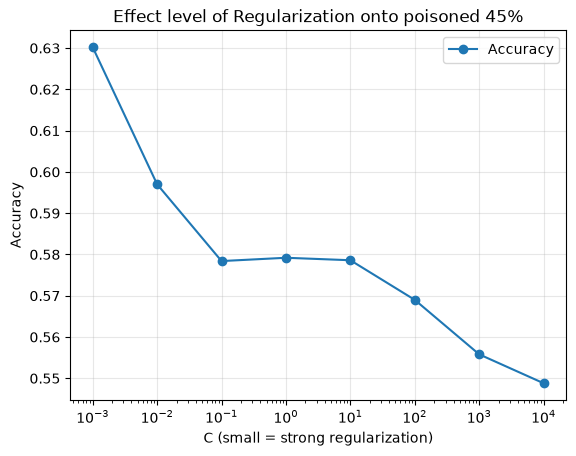

In [5]:
plt.plot(results_C_df["val"], results_C_df["acc"], marker="o", label="Accuracy")
plt.xscale("log")   
plt.xlabel("C (small = strong regularization)")
plt.ylabel("Accuracy")
plt.title(f"Effect level of Regularization onto poisoned {pl_rs}%")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 1.3. Kết luận

**Kết quả:**

| C | Accuracy |
|---|---|
| 10⁻³ (regularization rất mạnh) | **≈ 0.630** |
| 10⁻² | ≈ 0.597 |
| 10⁻¹ | ≈ 0.578 |
| 10⁰ | ≈ 0.579 |
| 10¹ | ≈ 0.578 |
| 10² | ≈ 0.569 |
| 10³ | ≈ 0.556 |
| 10⁴ (regularization gần như không có) | ≈ 0.549 |

Xu hướng chung rõ ràng: **`C` càng nhỏ (regularization càng mạnh) → accuracy càng cao**. Có một "vùng phẳng" hẹp quanh `C = 10⁻¹` đến `10¹` (accuracy gần như đi ngang ~0.578–0.579), nhưng ngoài vùng đó xu hướng vẫn tiếp diễn rõ rệt ở cả hai đầu: tăng mạnh khi `C` giảm xuống `10⁻²` và `10⁻³` (đạt đỉnh ~0.630), và **tiếp tục giảm** khi `C` tăng lên `10²`, `10³`, `10⁴` (xuống còn ~0.549) — chứ không hề "ổn định" trên toàn dải `C ≥ 1` như một mặt bằng phẳng.

Ở `C = 10⁻³`, accuracy đạt ~63%, cao hơn khoảng **8 điểm %** so với mức thấp nhất quan sát được (~55% ở `C = 10⁴`) — cho thấy regularization mạnh không chỉ tốt hơn mức "không regularization" (`C = 1`, ~58%), mà việc để regularization quá yếu (`C` rất lớn) còn khiến accuracy giảm sâu hơn nữa.

Mức cải thiện này là **có thật nhưng khiêm tốn** — regularization một mình không thể đưa accuracy quay lại gần mức 96% của mô hình sạch, cho thấy đây là một biện pháp giảm thiểu (mitigation) một phần, không phải giải pháp triệt để cho tấn công label flipping ở mức 45%.

## 2. Self - Cleaning

**Ý tưởng:** thay vì kìm hãm mô hình bằng regularization, hướng tiếp cận này cố **lọc bỏ trực tiếp** những mẫu huấn luyện bị nghi ngờ là nhãn sai, trước khi huấn luyện — dựa trên một tiêu chí nào đó (hàm `cleaning()` trong `src/defend`, ví dụ có thể dựa trên độ tin cậy dự đoán hoặc mức độ bất thường của mẫu). Tham số `keep_ratio` quyết định giữ lại bao nhiêu % dữ liệu train sau khi lọc (giữ lại các mẫu "đáng tin cậy" nhất theo tiêu chí đó).

### 2.1. Chuẩn bị

Hàm `defend_sc(poisoned_level, krs)`:
- Lấy `X_train`, `y_train` từ `train_dfs[str(poisoned_level)]`, scale bằng `StandardScaler` riêng.
- Huấn luyện một mô hình **baseline** (`lr_p`, không lọc gì cả) trên toàn bộ `X_train` đã scale, tính `acc_b` trên `X_test_scaled` — dùng làm đường tham chiếu "trước khi lọc".
- Với mỗi `keep_ratio` trong `krs` (lấy từ `config["keep-ratios"]`), gọi `cleaning(X_train, y_train, keep_ratio)` để lọc ra `X_cleaned`, `y_cleaned`, rồi huấn luyện lại Logistic Regression trên tập đã lọc và đánh giá trên `X_test_scaled`.
- Có bước bảo vệ: nếu sau khi lọc mà `y_cleaned` chỉ còn 1 lớp duy nhất (lọc quá tay, mất hết một nhãn) thì bỏ qua điểm đó, tránh lỗi khi huấn luyện.
- Chạy với `poisoned_level = 45`.

In [6]:
def defend_sc(poisoned_level, krs):
    result = []
    
    dt_train = train_dfs[poisoned_level]

    X_train, y_train = dt_train["X"], dt_train["attack"]

    sc = StandardScaler()
    X_train = sc.fit_transform(X_train)
    X_test_scaled = sc.transform(X_test)

    lr_p = LogisticRegression(
        max_iter=config["model"]["lr"]["max-iter"],
        random_state=config["model"]["lr"]["random-state"]
    ).fit(X_train, y_train)
    acc_b = accuracy_score(y_test, lr_p.predict(X_test_scaled))

    for kr in krs:
        X_cleaned, y_cleaned = cleaning(
            X_train, 
            y_train,
            kr
        )

        # If cleaning only have one style,
        # This mean just has 0 or 1
        # We will skip this data
        if len(np.unique(y_cleaned)) < 2: continue

        lr_cleaned = LogisticRegression(
            max_iter=config["model"]["lr"]["max-iter"],
            random_state=config["model"]["lr"]["random-state"]
        ).fit(X_cleaned, y_cleaned)

        result.append({
            "val": kr,
            "acc": accuracy_score(y_test, lr_cleaned.predict(X_test_scaled)),
            "w_norm": np.linalg.norm(lr_cleaned.coef_)
        })

    return acc_b, result

In [7]:
# Chaing poisoned level to see difference 
pl_sc = 45    
keep_ratios = config["keep-ratios"]

acc_b, result_kr = defend_sc(pl_sc, keep_ratios)
results_kr_df = pd.DataFrame(result_kr)

### 2.2. Vẽ biểu đồ

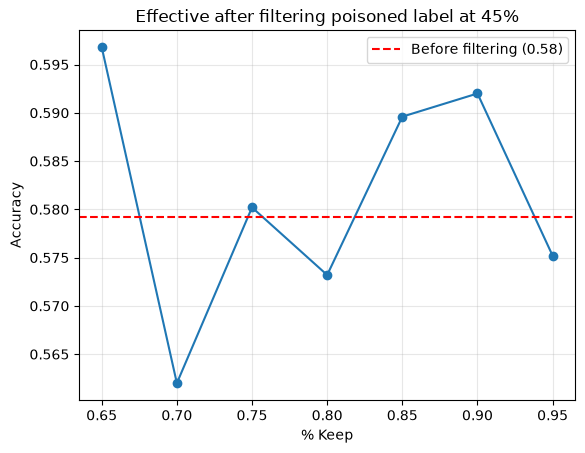

In [8]:
plt.plot(results_kr_df["val"], results_kr_df["acc"], marker="o")
plt.axhline(acc_b, color="red", linestyle="--", label=f"Before filtering ({acc_b:.2f})")
plt.xlabel("% Keep")
plt.ylabel("Accuracy")
plt.title(f"Effective after filtering poisoned label at {pl_sc}%")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 2.3. Kết luận

**Kết quả:** (baseline trước khi lọc: **acc_b ≈ 0.579**)

| % Keep | Accuracy | So với baseline |
|---|---|---|
| 0.65 | ≈ 0.597 | cao hơn rõ (cao nhất) |
| 0.70 | ≈ 0.562 | thấp hơn rõ (thấp nhất) |
| 0.75 | ≈ 0.580 | xấp xỉ (nhẹ cao hơn) |
| 0.80 | ≈ 0.573 | thấp hơn |
| 0.85 | ≈ 0.590 | cao hơn rõ |
| 0.90 | ≈ 0.592 | cao hơn rõ |
| 0.95 | ≈ 0.575 | thấp hơn (nhẹ) |

Không giống Regularization Sweep (có xu hướng đơn điệu, dễ diễn giải), kết quả Self-Cleaning ở đây **dao động quanh baseline** mà không cho thấy một xu hướng đơn điệu rõ ràng theo `keep_ratio` — có những điểm cải thiện khá rõ (0.65, 0.85, 0.90), có điểm gần như không đổi (0.75), và có điểm tệ hơn cả baseline (0.70, 0.80, 0.95, trong đó 0.70 là điểm tệ nhất). Biên độ dao động (0.562 – 0.597, tức khoảng ±1.8 điểm % quanh baseline) tương đương với mức cải thiện ~5–8 điểm % quan sát được ở Regularization Sweep, nhưng ở đây nó **dao động cả hai chiều** thay vì cải thiện có hệ thống.

Điều này gợi ý vài khả năng cần kiểm chứng thêm trước khi kết luận Self-Cleaning "có tác dụng" hay không:
- Kết quả mới chạy **1 lần duy nhất** cho mỗi `keep_ratio` — nên lẫn nhiễu ngẫu nhiên từ chính cách hàm `cleaning()` chọn mẫu để loại bỏ ở từng ngưỡng. Nên chạy lặp lại nhiều lần (hoặc trên nhiều tập con) rồi lấy trung bình ± độ lệch chuẩn để có kết luận đáng tin cậy hơn.
- Có thể tiêu chí lọc trong `cleaning()` chưa đủ tốt để phân biệt mẫu bị đảo nhãn khỏi mẫu hợp lệ ở mức đầu độc 45% (tỉ lệ nhiễu quá cao khiến tiêu chí lọc mất độ chính xác).

## 3. Kết hợp Regularization và Cleaning

**Ý tưởng:** Regularization Sweep (mục 1) và Self-Cleaning (mục 2) là hai hướng phòng thủ độc lập, mỗi hướng chỉ cải thiện accuracy một phần (~5–8 điểm % so với baseline ~58%) và không hoàn toàn ổn định. Phần này thử **kết hợp cả hai theo dạng lưới (grid search)**: quét đồng thời qua nhiều giá trị `keep_ratio` (mục 2) và nhiều giá trị `C` (mục 1), để xem việc lọc dữ liệu trước rồi huấn luyện với regularization phù hợp có tạo ra hiệu quả cộng hưởng (synergy) vượt trội hơn từng biện pháp riêng lẻ hay không.

### 3.1. Chuẩn bị

Hàm `defend_rs_sc(poisoned_level, kr, C_vals)`:
- Lấy `X_train`, `y_train` từ `train_dfs[str(poisoned_level)]`, scale bằng `StandardScaler` riêng (giống mục 1 và 2).
- Với mỗi giá trị `C_val` trong `C_vals`, gọi `cleaning(X_train, y_train, kr, C_val)` để lọc dữ liệu ứng với mức `keep_ratio = kr` đang xét (khác với mục 2, ở đây `cleaning()` nhận thêm tham số `C_val`), sau đó huấn luyện một Logistic Regression (`C` mặc định) trên tập đã lọc và đo accuracy trên `X_test_scaled`.
- Vòng lặp bên ngoài quét qua từng `keep_ratio` trong `keep_ratios` (mục 2), với mỗi mức lại gọi `rs_sc(...)` để quét toàn bộ `C_vals` (mục 1) bên trong → kết quả cuối là một lưới **8 × 7** (8 giá trị `C` × 7 giá trị `keep_ratio`), tất cả đều chạy trên `poisoned_level = 45`.

In [9]:
def defend_rs_sc(poisoned_level, kr, C_vals):
    result = {}

    sc = StandardScaler()

    X_train, y_train = train_dfs[poisoned_level]["X"], train_dfs[poisoned_level]["attack"]

    # Scalling
    X_train = sc.fit_transform(X_train)
    X_test_scaled = sc.transform(X_test)

    for C_val in C_vals:
        X_cleaned, y_cleaned = cleaning(
            X_train,
            y_train,
            kr,
            C_val
        )

        lr_cleaned = LogisticRegression(
            random_state=config["model"]["lr"]["random-state"],
            max_iter=config["model"]["lr"]["max-iter"]
        ).fit(X_cleaned, y_cleaned)

        result[C_val] = {
            "acc": accuracy_score(y_test, lr_cleaned.predict(X_test_scaled))
        }

    return result

In [10]:
pl_rs_sc = 45

result_rs_sc = {}

for kr in keep_ratios:
    result_rs_sc[kr] = defend_rs_sc(pl_rs_sc, kr, C_vals)

result_rs_sc_df = pd.DataFrame(result_rs_sc)

### 3.2. Vẽ biểu đồ

Trực quan hóa lưới kết quả 8×7 theo hai cách bổ sung cho nhau: line chart (dễ so sánh xu hướng theo `keep_ratio` ứng với từng `C`) và heatmap (dễ nhìn tổng thể toàn bộ lưới và xác định nhanh vùng tham số tốt nhất).

#### 3.2.1. Line Chart

Mỗi đường ứng với một giá trị `C`; trục hoành là `keep_ratio`, trục tung là accuracy.

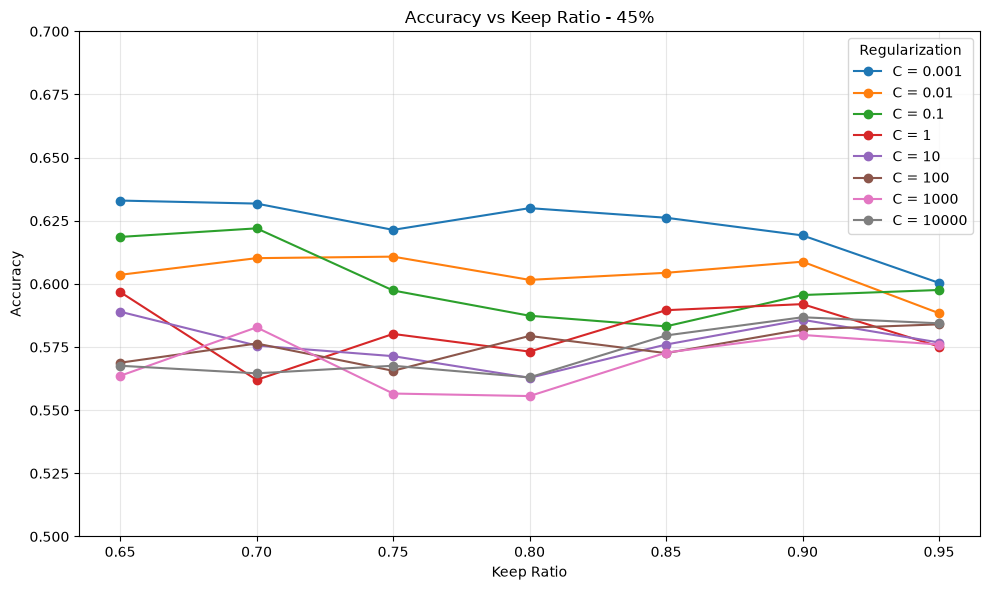

In [11]:
result_plot_df = result_rs_sc_df.map(
    lambda x: x["acc"] if isinstance(x, dict) else x
)

plt.figure(figsize=(10, 6))

for C in result_plot_df.index:
    plt.plot(
        result_plot_df.columns,
        result_plot_df.loc[C],
        marker="o",
        label=f"C = {C:g}"
    )

plt.title(f"Accuracy vs Keep Ratio - {pl_rs_sc}%")
plt.xlabel("Keep Ratio")
plt.ylabel("Accuracy")

plt.xticks(result_plot_df.columns)

plt.ylim(0.5, 0.7)
plt.grid(True, alpha=0.3)
plt.legend(title="Regularization")

plt.tight_layout()
plt.show()

#### 3.2.2. Heatmap

Mỗi ô là accuracy ứng với một cặp `(C, keep_ratio)` cụ thể; màu càng đậm thì accuracy càng cao — giúp xác định nhanh vùng tham số cho kết quả tốt nhất trong toàn bộ lưới.

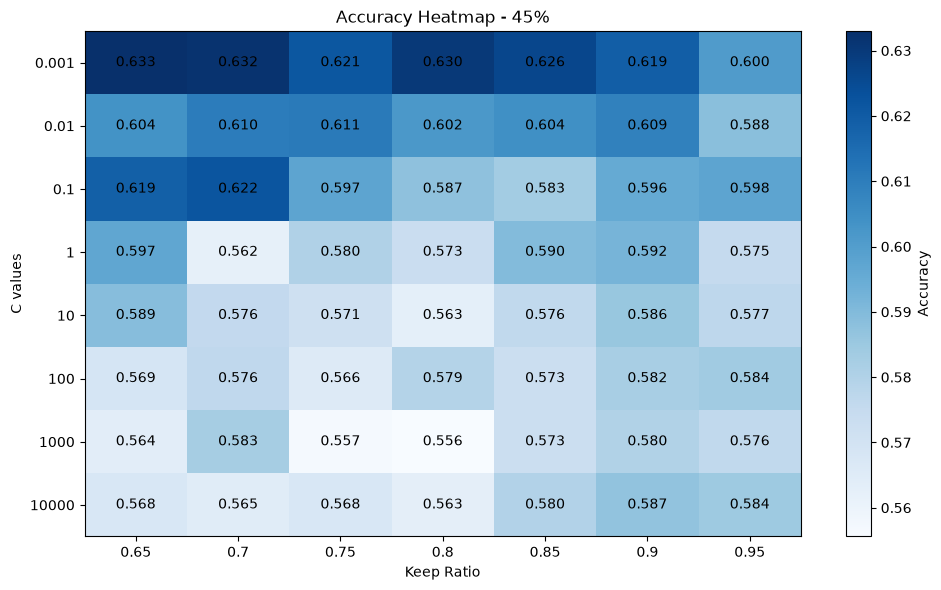

In [12]:
plt.figure(figsize=(10, 6))

plt.imshow(result_plot_df.values, aspect="auto", cmap="Blues")

plt.xticks(
    range(len(result_plot_df.columns)),
    result_plot_df.columns
)

plt.yticks(
    range(len(result_plot_df.index)),
    [f"{C:g}" for C in result_plot_df.index]
)

plt.xlabel("Keep Ratio")
plt.ylabel("C values")
plt.title(f"Accuracy Heatmap - {pl_rs_sc}%")

for i in range(len(result_plot_df.index)):
    for j in range(len(result_plot_df.columns)):
        value = result_plot_df.iloc[i, j]
        plt.text(
            j, i,
            f"{value:.3f}",
            ha="center",
            va="center"
        )

plt.colorbar(label="Accuracy")
plt.tight_layout()
plt.show()

### 3.3. Kết luận

**Kết quả:** (giá trị chính xác xem heatmap ở trên; bảng dưới là trung bình theo từng `C` trên cả 7 mức `keep_ratio`)

| C | Accuracy TB (7 mức keep_ratio) | Accuracy cao nhất trong hàng |
|---|---|---|
| 10⁻³ | ≈ 0.623 | **0.633** (tại `keep_ratio = 0.65`) |
| 10⁻² | ≈ 0.604 | 0.611 |
| 10⁻¹ | ≈ 0.600 | 0.622 |
| 10⁰ | ≈ 0.581 | 0.597 |
| 10¹ | ≈ 0.577 | 0.589 |
| 10² | ≈ 0.576 | 0.584 |
| 10³ | ≈ 0.570 | 0.583 |
| 10⁴ | ≈ 0.574 | 0.587 |

Kết quả tốt nhất trong toàn bộ lưới 8×7 là **0.633**, đạt được tại `C = 0.001` và `keep_ratio = 0.65` — gần như trùng với mức tốt nhất đã quan sát được khi chỉ dùng Regularization Sweep một mình ở mục 1.3 (**≈ 0.630**, tại `C = 10⁻³`, không lọc dữ liệu). Chênh lệch chỉ **~0.3 điểm %**, nằm trong biên độ nhiễu đã quan sát được ở Self-Cleaning một mình (±1.8 điểm %, mục 2.3) — tức là **không đủ để khẳng định có hiệu ứng cộng hưởng (synergy)** thực sự giữa hai kỹ thuật.

Nhìn theo hàng (`C` cố định, quét `keep_ratio`): tại mỗi mức `C`, accuracy vẫn dao động lên xuống theo `keep_ratio` với biên độ tương tự Self-Cleaning một mình (khoảng 1–3 điểm %) — việc thêm regularization không làm cho cleaning tạo ra một xu hướng đơn điệu rõ ràng hơn.

Nhìn theo cột (`keep_ratio` cố định, quét `C`): xu hướng "C nhỏ → accuracy cao" của Regularization Sweep vẫn giữ nguyên và là **yếu tố chi phối chính** của cả lưới kết quả — accuracy trung bình giảm gần như đơn điệu từ ≈0.623 (`C = 10⁻³`) xuống còn ≈0.57–0.58 khi `C ≥ 1`, khớp với mô hình đã thấy ở mục 1.3.

→ **Kết luận cho mục 3:** với dữ liệu đầu độc 45% nhãn, việc kết hợp Self-Cleaning với Regularization **không cho thấy hiệu quả cộng hưởng rõ rệt** — kết quả tốt nhất của lưới kết hợp gần như chỉ bằng kết quả tốt nhất của Regularization Sweep một mình. Regularization (điều chỉnh `C`) vẫn là yếu tố quyết định chính đến accuracy; Self-Cleaning ở dạng hiện tại chủ yếu đóng góp nhiễu ngẫu nhiên hơn là một tín hiệu cải thiện có hệ thống, kể cả khi kết hợp với các mức regularization khác nhau.

## 4. Cross Validation

**Ý tưởng:** ở mục 2, `cleaning()` chấm điểm độ tin cậy của từng mẫu bằng một mô hình đã được huấn luyện trên **chính các mẫu đó** (kể cả nhãn sai), nên mô hình có thể "thuộc lòng" luôn những nhãn bị đảo và không còn phân biệt được chúng — đây chính là giới hạn đã nêu ở cuối mục 2.3. Cross-Validation Filtering (CV filtering) xử lý điểm yếu này bằng cách chia dữ liệu thành `k` fold: mỗi mẫu được dự đoán bởi một mô hình **chưa từng nhìn thấy nó** (dự đoán *out-of-fold*). Những mẫu mà dự đoán out-of-fold mâu thuẫn với nhãn hiện có (theo ngưỡng `threshold`) bị đánh dấu là nghi ngờ và loại khỏi tập huấn luyện, sau đó mô hình cuối được huấn luyện lại trên phần dữ liệu còn lại. 

Có hai siêu tham số cần khảo sát:
- `k` (số fold): 3, 5, 10 — ảnh hưởng đến mức "sạch" của dự đoán out-of-fold (mỗi mô hình phụ được huấn luyện trên `(k-1)/k` dữ liệu) và chi phí tính toán (`k` lần fit).
- `threshold`: 0.5 → 0.9 — quyết định mức "nghiêm khắc" khi gắn cờ mẫu nghi ngờ, tức là **lọc nhiều hay ít**.

Khác với Self-Cleaning (mục 2) là giữ cố định `keep_ratio`, ở đây **số mẫu bị loại do dữ liệu và `threshold` quyết định**, không được đặt trước.

### 4.1. Chuẩn bị

Hàm `defend_cv(poisoned_level, k=5, threshold=0.5)`:
- Lấy `X_train`, `y_train` từ `train_dfs[poisoned_level]`, scale bằng `StandardScaler` fit riêng trên tập train (giống các mục trước), rồi áp dụng scaler đó lên `X_test`.
- Tạo `model_factory` — mỗi lần gọi trả về một Logistic Regression mới, để `cv_filter` huấn luyện độc lập trên từng fold.
- Gọi `cv_filter(X_train_scaled, y_train, model_factory, k, threshold)` để lấy `suspicious_idx` (chỉ số các mẫu nghi ngờ nhãn sai), dựng `keep_mask` rồi loại các mẫu này.
- Huấn luyện lại Logistic Regression (**`C` mặc định**, chưa dùng regularization của mục 1) trên tập đã lọc và đo accuracy trên `X_test_scaled`.
- Trả về `acc`, `n_flagged` (số mẫu bị loại) và `n_kept` (số mẫu giữ lại). Hai giá trị sau được lưu trong `result_cv_df` nhưng chưa được vẽ; nên in ra để đối chiếu mức lọc thực tế ứng với từng `threshold`.
- Chạy lưới **3 × 5** (`k` ∈ {3, 5, 10} × `threshold` ∈ {0.5, 0.6, 0.7, 0.8, 0.9}) trên `poisoned_level = 45`.

In [13]:
def defend_cv(poisoned_level, k=5, threshold=0.5):
    sc = StandardScaler()

    X_train = train_dfs[poisoned_level]["X"]
    y_train = train_dfs[poisoned_level]["attack"]

    X_train_scaled = sc.fit_transform(X_train)                
    X_test_scaled = sc.transform(X_test)

    model_factory = lambda: LogisticRegression(
        max_iter=config["model"]["lr"]["max-iter"],
        random_state=config["model"]["lr"]["random-state"]
    )

    # Find negative samples by CV filtering
    suspicious_idx = cv_filter(X_train_scaled, y_train, model_factory, k=k, threshold=threshold)

    # Drop out those samples
    keep_mask = np.ones(len(y_train), dtype=bool)
    keep_mask[suspicious_idx] = False
    X_cleaned, y_cleaned = X_train_scaled[keep_mask], y_train[keep_mask]

    # Training model with new data
    lr_final = LogisticRegression(
        max_iter=config["model"]["lr"]["max-iter"],
        random_state=config["model"]["lr"]["random-state"]
    ).fit(X_cleaned, y_cleaned)

    acc = accuracy_score(y_test, lr_final.predict(X_test_scaled))

    return {
        "acc": acc,
        "n_flagged": len(suspicious_idx),
        "n_kept": keep_mask.sum()
    }

In [14]:
pl_cv = 45

k_vals = config["k-values"]
threshold_vals = config["threshold-values"]

result_cv = {}

for k_val in k_vals:
    result_k_val = {}
    for threshold_val in threshold_vals:
        result_k_val[threshold_val] = defend_cv(pl_cv, k_val, threshold_val)
    result_cv[k_val] = result_k_val 

result_cv_df = pd.DataFrame(result_cv)

### 4.2. Vẽ biểu đồ

#### 4.2.1 Line Chart.

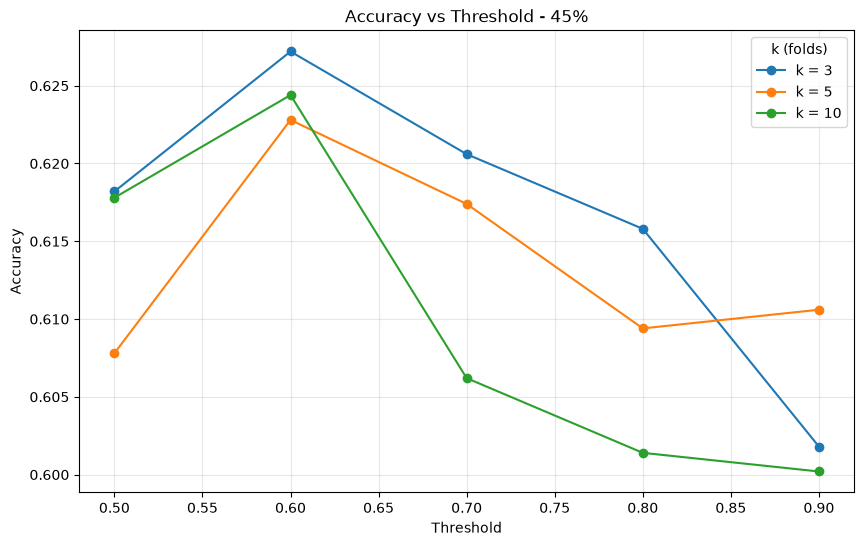

In [17]:
acc_df = result_cv_df.map(lambda x: x["acc"])

plt.figure(figsize=(10, 6))
for k in acc_df.columns:
    plt.plot(acc_df.index, acc_df[k], marker="o", label=f"k = {k}")

plt.title(f"Accuracy vs Threshold - {pl_cv}%")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.legend(title="k (folds)")
plt.grid(True, alpha=0.3)
plt.show()

#### 4.2.2. Heatmap

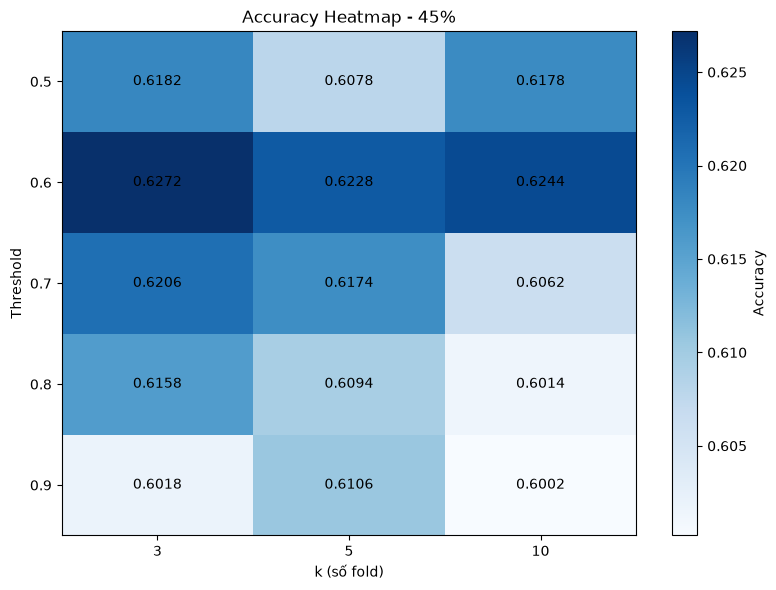

In [16]:
plt.figure(figsize=(8, 6))
plt.imshow(acc_df.values, cmap="Blues", aspect="auto")

plt.xticks(ticks=np.arange(len(acc_df.columns)), labels=acc_df.columns)
plt.yticks(ticks=np.arange(len(acc_df.index)), labels=acc_df.index)

plt.xlabel("k (số fold)")
plt.ylabel("Threshold")
plt.title(f"Accuracy Heatmap - {pl_cv}%")
plt.colorbar(label="Accuracy")

for i in range(acc_df.shape[0]):
    for j in range(acc_df.shape[1]):
        plt.text(j, i, f"{acc_df.values[i, j]:.4f}", ha="center", va="center")

plt.tight_layout()
plt.show()

### 4.3. Kết luận

**Kết quả:** (baseline trước khi lọc ở mục 2: **acc_b ≈ 0.579**; giá trị chính xác xem heatmap ở 4.2.2)

| Threshold \ k | k = 3 | k = 5 | k = 10 | TB theo threshold |
|---|---|---|---|---|
| 0.5 | 0.6182 | 0.6078 | 0.6178 | ≈ 0.615 |
| 0.6 | **0.6272** | 0.6228 | 0.6244 | **≈ 0.625** |
| 0.7 | 0.6206 | 0.6174 | 0.6062 | ≈ 0.615 |
| 0.8 | 0.6158 | 0.6094 | 0.6014 | ≈ 0.609 |
| 0.9 | 0.6018 | 0.6106 | 0.6002 | ≈ 0.604 |
| **TB theo k** | ≈ 0.617 | ≈ 0.614 | ≈ 0.610 | ≈ 0.613 |

**Nhận xét:**

1. **Cải thiện nhất quán so với baseline.** Cả **15/15 cấu hình** đều cao hơn baseline 0.579: từ +2.1 điểm % (0.6002) đến +4.8 điểm % (0.6272), trung bình khoảng +3.4 điểm %. Đây là điểm khác biệt rõ nhất so với Self-Cleaning (mục 2), nơi 3/7 mức `keep_ratio` cho kết quả *thấp hơn* baseline.
2. **`threshold` là yếu tố chi phối, đỉnh tại 0.6.** Cả ba đường `k` đều đạt cao nhất tại `threshold = 0.6`, rồi giảm khi tăng lên 0.7–0.9 (giảm khoảng 1.2–2.5 điểm %); tại 0.5 accuracy cũng thấp hơn 0.6. Đường cong có dạng "hình chuông" — gợi ý rằng lọc quá ít thì còn sót nhãn sai, còn lọc quá tay thì loại nhầm cả mẫu đúng. Cách giải thích này **cần đối chiếu với `n_flagged` / `n_kept`** (đã lưu trong `result_cv_df` nhưng chưa in) trước khi coi là kết luận.
3. **`k` ít ảnh hưởng.** Tại cùng một `threshold`, chênh lệch giữa các `k` chỉ ≤ ~1.4 điểm % (tại 0.6 chỉ ~0.4 điểm %) — nằm trong biên nhiễu đã quan sát ở mục 2.3. `k = 3` nhỉnh nhất ở 4/5 mức `threshold`, trong khi `k = 10` tốn hơn ~3 lần số lần fit mà không cho kết quả tốt hơn → `k = 3` là lựa chọn kinh tế nhất trong lưới này.
4. **So với các hướng khác.** Kết quả tốt nhất (**0.6272**, `k = 3`, `threshold = 0.6`) thấp hơn Regularization Sweep một mình (≈ 0.630) và lưới kết hợp (≈ 0.633) khoảng 0.3–0.6 điểm % — nằm trong biên nhiễu nên chưa thể nói CV filtering tốt hơn hay kém hơn Regularization về accuracy đỉnh. Tuy nhiên nó **vượt rõ Self-Cleaning** (đỉnh 0.597, trung bình ≈ 0.581 so với ≈ 0.613 ở đây). Một lý do khả dĩ: dự đoán out-of-fold không để mô hình "tự xác nhận" chính nhãn sai mà nó đã học.
5. **Giới hạn.** Accuracy tốt nhất vẫn còn cách baseline sạch (~96%) khoảng 33 điểm %. Mô hình cuối dùng `C` mặc định nên chưa tận dụng regularization; mỗi cấu hình chỉ chạy **1 lần**; và `cv_filter` vẫn dùng Logistic Regression huấn luyện trên nhãn nhiễu 45% để phát hiện nhãn sai — nên giới hạn cốt lõi (mô hình dùng để lọc cũng đã bị đầu độc) chỉ được giảm nhẹ chứ chưa được loại bỏ.

→ **Kết luận cho mục 4:** CV filtering là hướng *lọc dữ liệu* ổn định nhất trong các hướng đã thử (15/15 cấu hình vượt baseline, đỉnh rõ tại `threshold = 0.6`, ít nhạy với `k`), nhưng mức cải thiện tối đa (~+4.8 điểm %) chỉ ngang chứ không vượt Regularization Sweep. Do mô hình cuối chưa dùng regularization, bước hợp lý tiếp theo là kết hợp CV filtering với `C` nhỏ (chưa được kiểm chứng ở mục 3, vì mục 3 chỉ kết hợp `cleaning()` với regularization).

## Kết luận

Notebook đã thử bốn hướng phòng thủ trên cùng mức đầu độc **45%** nhãn (baseline nhiễu ≈ **0.579**, baseline sạch ≈ **0.96**). Các hướng được so sánh theo những tiêu chí đã dùng xuyên suốt các mục trên:

1. **Mức cải thiện accuracy** so với baseline nhiễu, và khoảng cách còn lại tới baseline sạch (~96%).
2. **Tính nhất quán / dễ diễn giải** (kết quả có xu hướng đơn điệu, dự đoán được hay không).
3. **Độ ổn định** trước nhiễu ngẫu nhiên (có cấu hình nào tệ hơn baseline không).
4. **Chi phí** tính toán và độ phức tạp.
5. **Mức phụ thuộc vào mô hình bị đầu độc** để phát hiện nhãn sai.
6. **Hiệu ứng cộng hưởng** khi kết hợp các kỹ thuật.

### Bảng 1. Kết quả định lượng (poisoned 45%)

| Hướng phòng thủ | Cấu hình tốt nhất | Acc cao nhất | Thay đổi so với baseline 0.579 (tệ nhất → tốt nhất) | Còn thiếu so với ~96% |
|---|---|---|---|---|
| **1. Regularization Sweep** | `C = 10⁻³` | 0.630 | −3.0 → **+5.1** điểm % | ~33 điểm % |
| **2. Self-Cleaning** | `keep_ratio = 0.65` | 0.597 | −1.7 → **+1.8** điểm % | ~36 điểm % |
| **3. Kết hợp (1 + 2)** | `C = 10⁻³`, `keep_ratio = 0.65` | **0.633** | −2.3 → **+5.4** điểm % | ~33 điểm % |
| **4. CV Filtering** | `k = 3`, `threshold = 0.6` | 0.627 | **+2.1 → +4.8** điểm % | ~33 điểm % |

*Lưu ý:* mức "tệ nhất" phụ thuộc vào dải giá trị đã quét — lưới của Regularization Sweep kéo dài tới `C = 10⁴` (gần như không regularization) nên có điểm rất thấp, còn lưới của CV Filtering hẹp hơn. Vì vậy cột này chỉ nên dùng để so sánh độ ổn định một cách tương đối.

### Bảng 2. Ưu điểm và nhược điểm

| Hướng | Ưu điểm | Nhược điểm |
|---|---|---|
| **1. Regularization Sweep** | • Đơn giản và rẻ nhất: chỉ đổi một tham số, không cần loại bỏ dữ liệu.<br>• Xu hướng đơn điệu, dễ diễn giải và dự đoán (`C` nhỏ → accuracy cao).<br>• Cải thiện lớn nhất trong các hướng đơn lẻ (+5.1 điểm %), gần ngang cả lưới kết hợp. | • Chỉ giảm thiểu một phần, không khôi phục được ~96%.<br>• Không xử lý gốc rễ: nhãn sai vẫn nằm trong dữ liệu huấn luyện.<br>• Điểm tốt nhất nằm ở **biên lưới** (`C = 10⁻³`) nên chưa biết đỉnh thực sự ở đâu.<br>• Nếu `C` quá lớn thì tệ hơn baseline (xuống 0.549). |
| **2. Self-Cleaning** | • Ý tưởng trực tiếp: loại mẫu nghi ngờ thay vì chỉ kìm hãm mô hình.<br>• Tiềm năng lý thuyết cao hơn regularization.<br>• Có cơ chế bảo vệ khi lọc làm mất một lớp nhãn. | • Kết quả dao động, không đơn điệu theo `keep_ratio`; 3/7 mức tệ hơn baseline.<br>• Cải thiện tốt nhất chỉ +1.8 điểm %, nằm gần biên nhiễu.<br>• Chấm điểm mẫu bằng chính mô hình đã fit trên dữ liệu nhiễu.<br>• Mất một phần dữ liệu khi `keep_ratio` < 1; mỗi mức chỉ chạy 1 lần. |
| **3. Kết hợp (1 + 2)** | • Quét toàn diện; cho accuracy cao nhất tuyệt đối (0.633).<br>• Xác nhận rõ `C` là yếu tố chi phối, giúp định hướng việc chọn tham số. | • **Không có cộng hưởng:** hơn Regularization một mình chỉ ~0.3 điểm %, trong biên nhiễu.<br>• Chi phí lớn nhất (lưới 8 × 7 = 56 cấu hình, mỗi cấu hình gồm lọc + huấn luyện).<br>• Phần `cleaning()` chủ yếu đóng góp nhiễu.<br>• Nhiều siêu tham số hơn → khó diễn giải, dễ chọn cấu hình "may mắn" trên tập test. |
| **4. CV Filtering** | • **Ổn định nhất** trong các hướng lọc: 15/15 cấu hình vượt baseline (+2.1 → +4.8 điểm %).<br>• Mỗi mẫu được chấm điểm bởi mô hình chưa thấy nó (out-of-fold).<br>• Đỉnh rõ tại `threshold = 0.6` ở cả ba mức `k`; ít nhạy với `k` nên `k = 3` là đủ.<br>• Có `n_flagged` / `n_kept` để kiểm soát mức lọc. | • Đỉnh (0.627) không vượt Regularization Sweep (0.630) và lưới kết hợp (0.633).<br>• Chi phí cao hơn Regularization (`k + 1` lần fit mỗi cấu hình).<br>• Vẫn dùng Logistic Regression huấn luyện trên nhãn nhiễu để phát hiện nhãn sai.<br>• Nhạy với `threshold` (0.9 thấp hơn 0.6 tới ~2.5 điểm %); mô hình cuối chưa dùng regularization; mỗi cấu hình chỉ chạy 1 lần. |

### Bảng 3. Đánh giá theo từng tiêu chí

| Tiêu chí | 1. Regularization | 2. Self-Cleaning | 3. Kết hợp | 4. CV Filtering |
|---|---|---|---|---|
| Mức cải thiện tối đa | Cao (+5.1) | Thấp (+1.8) | Cao (+5.4) | Cao (+4.8) |
| Khôi phục tới ~96% | Không | Không | Không | Không |
| Nhất quán / dễ diễn giải | **Tốt** — đơn điệu theo `C` | Yếu — dao động | Trung bình — `C` chi phối, `keep_ratio` dao động | Khá — có đỉnh rõ, ít nhạy `k` |
| Độ ổn định (so với baseline) | Trung bình — tệ hơn baseline khi `C ≥ 10²` | Yếu — 3/7 mức tệ hơn | Trung bình — phần lớn ô ở `C ≥ 10` thấp hơn baseline | **Tốt** — 15/15 cao hơn |
| Chi phí | **Thấp** | Thấp – trung bình | Cao | Trung bình |
| Phụ thuộc mô hình bị đầu độc | Không lọc, nhưng vẫn học từ nhãn nhiễu | Cao | Cao | Trung bình — out-of-fold nhưng vẫn cùng kiến trúc |
| Cộng hưởng khi kết hợp | — | — | **Không có** | Chưa kiểm chứng với `C` |

### Nhận định chung

- **Regularization Sweep** là lựa chọn thực dụng nhất: đơn giản, rẻ, dễ diễn giải và đạt mức cải thiện ngang với hướng tốt nhất (~+5 điểm % so với baseline nhiễu).
- **CV Filtering** là hướng lọc dữ liệu đáng tin cậy nhất: ổn định hơn hẳn Self-Cleaning, gần ngang Regularization về accuracy đỉnh, nhưng chi phí cao hơn và không vượt được nó.
- **Kết hợp Regularization + Cleaning** đạt số cao nhất (0.633) chỉ vì đã chứa `C = 10⁻³`; với chi phí lớn nhất mà không có cộng hưởng, hướng này **không đáng đầu tư** ở dạng hiện tại.
- **Self-Cleaning** yếu nhất: kết quả dao động quanh baseline, cải thiện tốt nhất không vượt rõ biên nhiễu.

Cả bốn hướng đều **không đưa accuracy quay lại gần ~96%**: tối đa chỉ cải thiện ≈ 5 điểm % so với baseline nhiễu 0.579 (≈ 8 điểm % nếu so với cấu hình tệ nhất là 0.549). Ở mức đầu độc 45%, các biện pháp *post-hoc* dựa trên regularization và/hoặc lọc theo dự đoán của mô hình chỉ **giảm thiểu một phần**, không vô hiệu hóa được tấn công label flipping. Giới hạn cốt lõi vẫn là các phương pháp lọc đều dùng một mô hình Logistic Regression huấn luyện trên nhãn nhiễu để đánh giá độ tin cậy của mẫu; dự đoán out-of-fold (CV Filtering) giúp ổn định hơn nhưng chưa giải quyết được vấn đề gốc.